In [30]:
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px

churn = pd.read_csv('churn.csv')
churn.shape

(505207, 12)

In [2]:
churn.info

<bound method DataFrame.info of         CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0              2.0  30.0  Female    39.0             14.0            5.0   
1              3.0  65.0  Female    49.0              1.0           10.0   
2              4.0  55.0  Female    14.0              4.0            6.0   
3              5.0  58.0    Male    38.0             21.0            7.0   
4              6.0  23.0    Male    32.0             20.0            5.0   
...            ...   ...     ...     ...              ...            ...   
505202    514369.0  45.0  Female    33.0             12.0            6.0   
505203    514370.0  37.0    Male     6.0              1.0            5.0   
505204    514371.0  25.0    Male    39.0             14.0            8.0   
505205    514372.0  50.0  Female    18.0             19.0            7.0   
505206    514373.0  52.0  Female    45.0             15.0            9.0   

        Payment Delay Subscription Type Contract Length

In [3]:
churn.columns = ['customerId', 'age', 'gender', 'tenure', 'usageFrequency', 
                 'supportCalls', 'paymentDelay', 'subscriptionType', 'contractLength', 
                 'totalSpend', 'lastTransaction', 'churn']

churn.head(20)
# churn.tail(20)

,customerId,age,gender,tenure,usageFrequency,supportCalls,paymentDelay,subscriptionType,contractLength,totalSpend,lastTransaction,churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
5,8.0,51.0,Male,33.0,25.0,9.0,26.0,Premium,Annual,129.0,8.0,1.0
6,9.0,58.0,Female,49.0,12.0,3.0,16.0,Standard,Quarterly,821.0,24.0,1.0
7,10.0,55.0,Female,37.0,8.0,4.0,15.0,Premium,Annual,445.0,30.0,1.0
8,11.0,39.0,Male,12.0,5.0,7.0,4.0,Standard,Quarterly,969.0,13.0,1.0
9,12.0,64.0,Female,3.0,25.0,2.0,11.0,Standard,Quarterly,415.0,29.0,1.0


In [4]:
# review for and remove missing or duplicated data

churn.duplicated().sum()
churn.isnull().sum()
churnMissingRow = churn[churn['age'].isnull()]
churnMissingRow

churn = churn.drop(index = [199295])
churn = churn.drop(columns = ['customerId'])
churn.shape

(505206, 11)

In [5]:
churn['genderNumeric'] = churn['gender']
churn['subscriptionNumeric'] = churn['subscriptionType']
churn['contractNumeric'] = churn['contractLength']
churn.head()

,age,gender,tenure,usageFrequency,supportCalls,paymentDelay,subscriptionType,contractLength,totalSpend,lastTransaction,churn,genderNumeric,subscriptionNumeric,contractNumeric
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0,Female,Standard,Annual
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0,Female,Basic,Monthly
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0,Female,Basic,Quarterly
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0,Male,Standard,Monthly
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0,Male,Basic,Monthly


In [10]:
crosstabGender = pd.crosstab(churn['churn'], churn['gender'])
crosstabGender

crosstabSub = pd.crosstab(churn['churn'], churn['subscriptionType'])
crosstabSub

crosstabLength = pd.crosstab(churn['churn'], churn['contractLength'])
crosstabLength

crosstabCalls = pd.crosstab(churn['churn'], churn['supportCalls'])
crosstabCalls

crosstabDelays = pd.crosstab(churn['churn'], churn['paymentDelay'], margins = True)
crosstabDelays

paymentDelay,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,All
churn,,,,,,,,,,,,,,,,,,,,,
0.0,10456,10620,10322,10472,10518,10352,10444,10512,10338,10372,...,672,602,667,646,658,670,664,633,636,224714
1.0,8042,7940,8031,8096,8008,7960,8051,8054,8113,8031,...,10603,10437,10406,10497,10506,10326,10361,10561,10728,280492
All,18498,18560,18353,18568,18526,18312,18495,18566,18451,18403,...,11275,11039,11073,11143,11164,10996,11025,11194,11364,505206


In [ ]:
# replacing the objects with ints

dictGender = {'genderNumeric': {'Male': 0, 'Female': 1}}
dictSubscription = {'subscriptionNumeric': {'Basic': 1, 'Premium': 2, 'Standard': 3}}
dictContract = {'contractNumeric': {'Annual': 1, 'Monthly': 2, 'Quarterly':3}}

churn.replace(dictGender, inplace = True)
churn.replace(dictSubscription, inplace = True)
churn.replace(dictContract, inplace = True)

churn.head()

/var/folders/kg/d_6ch9gj3nz03_0kd2x0c_hr0000gn/T/ipykernel_45385/1217021025.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  churn.replace(dictContract, inplace = True)


,age,gender,tenure,usageFrequency,supportCalls,paymentDelay,subscriptionType,contractLength,totalSpend,lastTransaction,churn,genderNumeric,subscriptionNumeric,contractNumeric
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0,1,3,1
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0,1,1,2
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0,1,1,3
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0,0,3,2
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0,0,1,2


In [15]:
churnNumeric = churn.copy()
churnNumeric.drop(['gender', 'contractLength', 'subscriptionType'], axis = 1, inplace = True)
churnNumeric.head()

,age,tenure,usageFrequency,supportCalls,paymentDelay,totalSpend,lastTransaction,churn,genderNumeric,subscriptionNumeric,contractNumeric
0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,1,3,1
1,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,1,1,2
2,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,1,1,3
3,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1.0,0,3,2
4,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1.0,0,1,2


In [16]:
# making sure everything is either an integer or a float
churnNumeric.info()

<class 'pandas.core.frame.DataFrame'>
Index: 505206 entries, 0 to 505206
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   age                  505206 non-null  float64
 1   tenure               505206 non-null  float64
 2   usageFrequency       505206 non-null  float64
 3   supportCalls         505206 non-null  float64
 4   paymentDelay         505206 non-null  float64
 5   totalSpend           505206 non-null  float64
 6   lastTransaction      505206 non-null  float64
 7   churn                505206 non-null  float64
 8   genderNumeric        505206 non-null  int64  
 9   subscriptionNumeric  505206 non-null  int64  
 10  contractNumeric      505206 non-null  int64  
dtypes: float64(8), int64(3)
memory usage: 46.3 MB


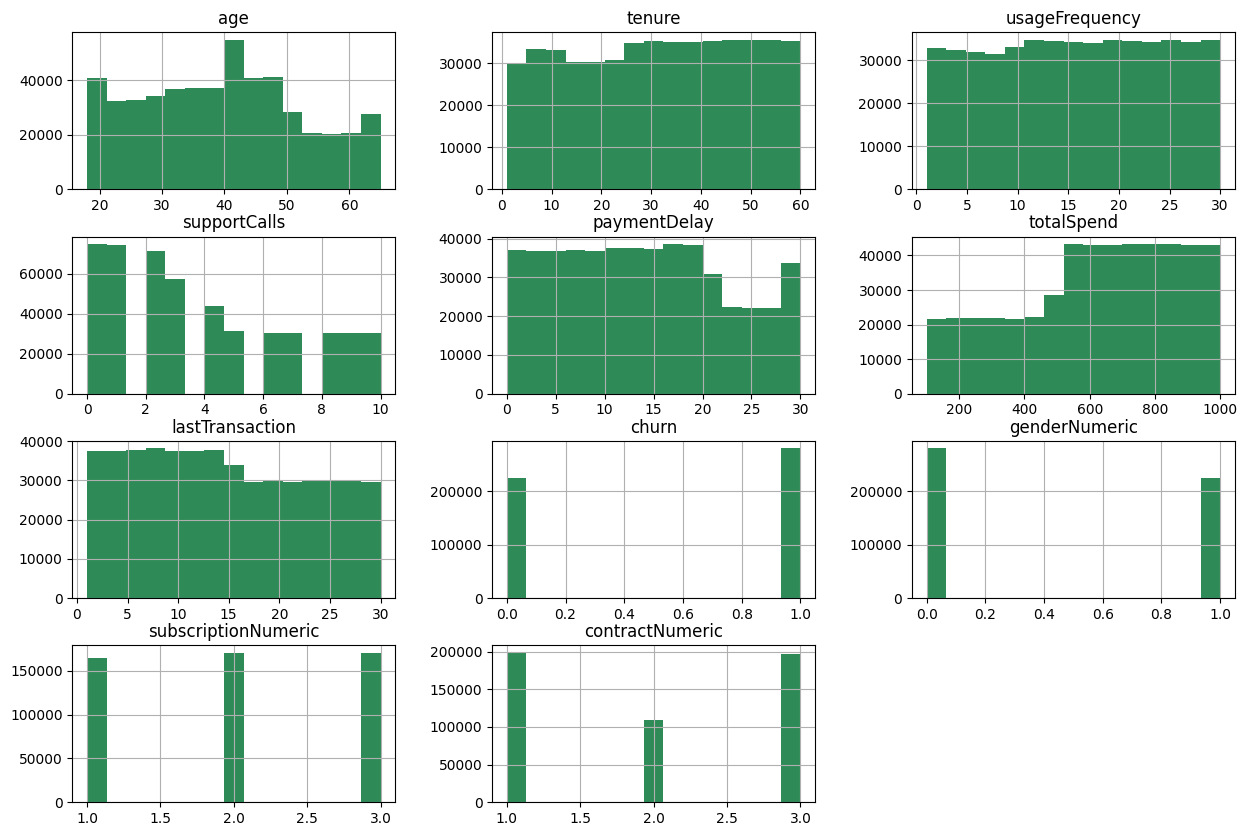

In [23]:
churnNumeric.hist(bins = 15, figsize = (15, 10), color = 'seagreen')
plt.show()

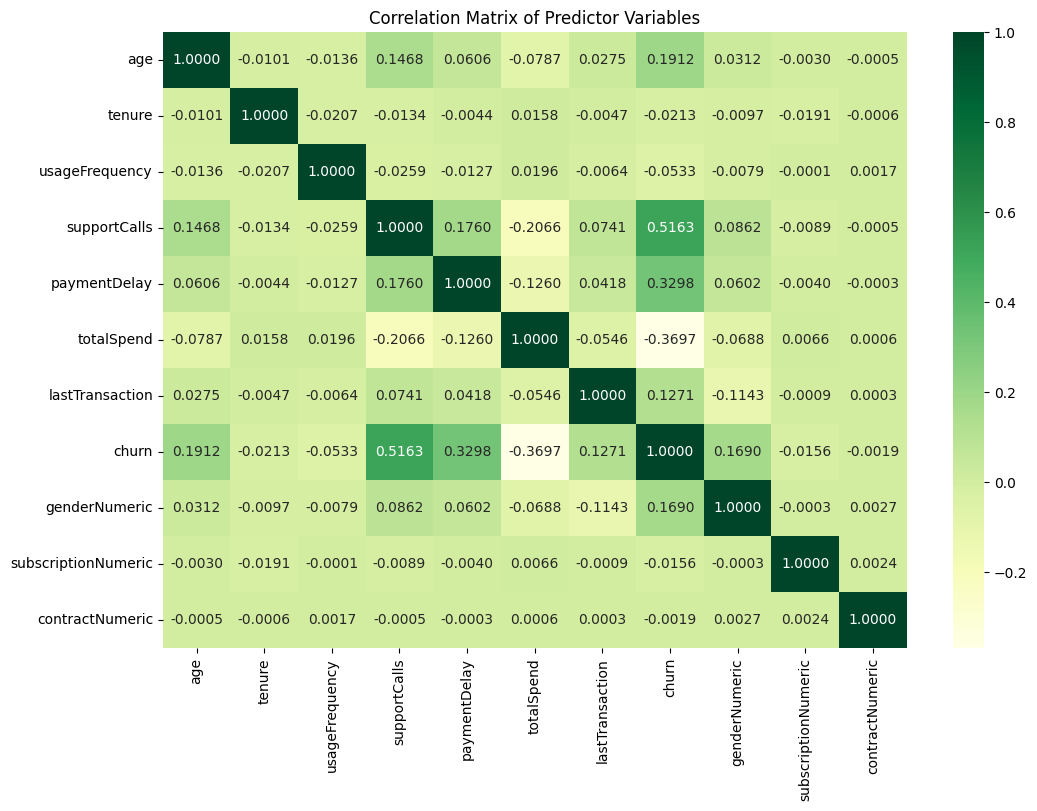

In [24]:
correlationMatrix = churnNumeric.corr()
plt.figure(figsize = (12, 8))
sns.heatmap(correlationMatrix, annot = True, fmt = ".4f", cmap = 'YlGn')
plt.title("Correlation Matrix of Predictor Variables")
plt.show()

In [29]:
churnNumeric['ageZ'] = stats.zscore(churnNumeric['age'])
churnNumeric['tenureZ'] = stats.zscore(churnNumeric['tenure'])
churnNumeric.head(20)
churnNumeric = churnNumeric.drop(columns = ['ageZ', 'tenureZ'])

<Axes: xlabel='Partition'>

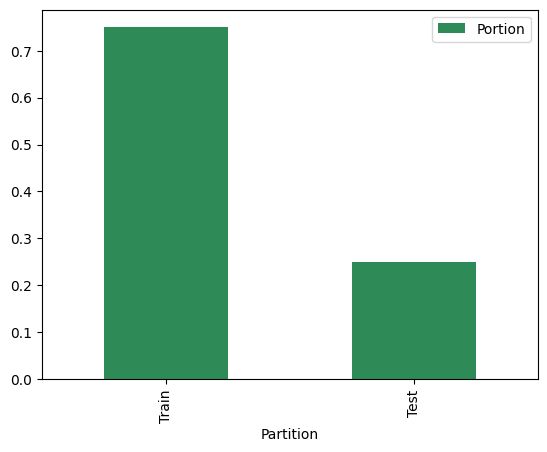

In [35]:
churnNumericTrain, churnNumericTest = train_test_split(churnNumeric, test_size = 0.25, random_state = 42)
df = pd.DataFrame({'Partition': ['Train', 'Test'], 'Portion': [(churnNumericTrain.shape[0]/churnNumeric.shape[0]),
                                                               (churnNumericTest.shape[0]/churnNumeric.shape[0])]})
df.set_index('Partition').plot(kind = 'bar', color = 'seagreen')

In [ ]:
# set-up + cart model

xTrain = churnNumericTrain.drop(columns = "churn")
xTest = churnNumericTest.drop(columns = "churn")
yTrain = churnNumericTrain["churn"]
yTest = churnNumericTest["churn"]

cart = DecisionTreeClassifier(criterion = "gini", max_leaf_nodes = 5).fit(xTrain, yTrain)
yPredCart = cart.predict(xTest)
mseCart = mean_squared_error(yTest, yPredCart)
maeCart = mean_absolute_error(yTest, yPredCart)
print(f"CART Algorithm Model - Mean Squared Error: {mseCart}")
print(f"CART Algorithm Model - Mean Absolute Error: {maeCart}")

CART Algorithm Model - Mean Squared Error: 0.10014884958274611
CART Algorithm Model - Mean Absolute Error: 0.10014884958274611


<function matplotlib.pyplot.show(close=None, block=None)>

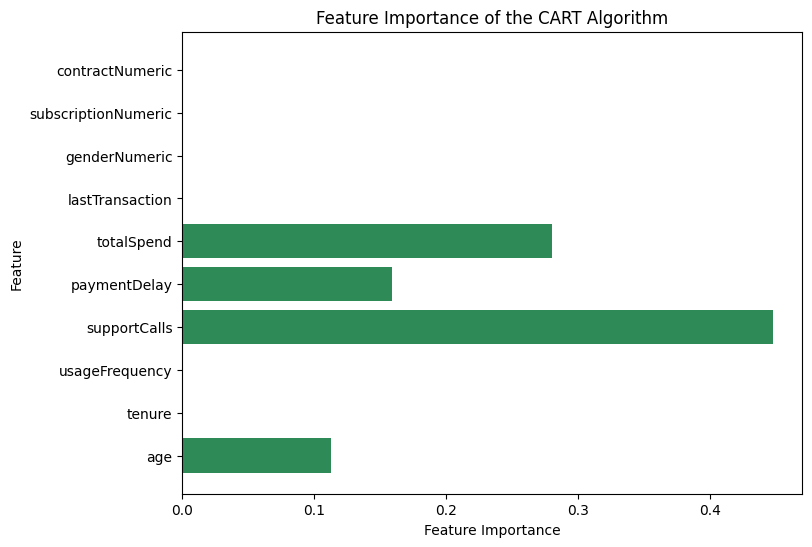

In [39]:
importance = cart.feature_importances_
xNames = xTrain.columns
featureNames = xNames

plt.figure(figsize = (8, 6))
plt.barh(range(xTrain.shape[1]), importance, align = 'center', color = 'seagreen')
plt.yticks(np.arange(xTrain.shape[1]), featureNames)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance of the CART Algorithm")
plt.show

In [ ]:
# random forest model

rf = RandomForestClassifier(n_estimators = 10, criterion = "gini").fit(xTrain, yTrain)
yPredRF = rf.predict(xTest)
mseRF = mean_squared_error(yTest, yPredRF)
maeRF = mean_absolute_error(yTest, yPredRF)
print(f"Random Forest Model - Mean Squared Error: {mseRF}")
print(f"Random Forest Model - Mean Absolute Error: {maeRF}")

Random Forest Model - Mean Squared Error: 0.07311048122753401
Random Forest Model - Mean Absolute Error: 0.07311048122753401


<function matplotlib.pyplot.show(close=None, block=None)>

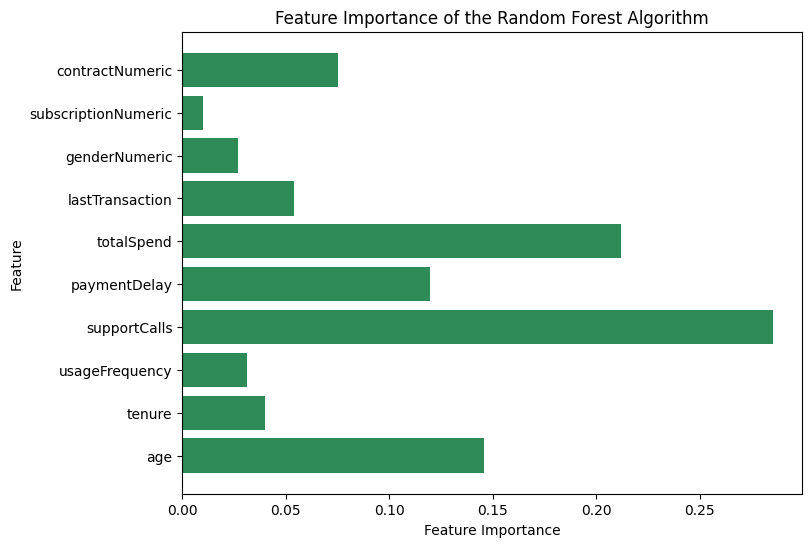

In [41]:
importance = rf.feature_importances_
xNames = xTrain.columns
featureNames = xNames

plt.figure(figsize = (8, 6))
plt.barh(range(xTrain.shape[1]), importance, align = 'center', color = 'seagreen')
plt.yticks(np.arange(xTrain.shape[1]), featureNames)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance of the Random Forest Algorithm")
plt.show

In [ ]:
# mlr model

xTrain = sm.add_constant(xTrain)
xTest = sm.add_constant(xTest)
reg = sm.OLS(yTrain, xTrain).fit()
yPredReg = reg.predict(xTest)

mseReg = mean_squared_error(yTest, yPredReg)
maeReg = mean_absolute_error(yTest, yPredReg)
print(f"Multiple Linear Regression Model - Mean Squared Error: {mseReg}")
print(f"Multiple Linear Regression Model - Mean Absolute Error: {maeReg}")

Multiple Linear Regression Model - Mean Squared Error: 0.1455504654422898
Multiple Linear Regression Model - Mean Absolute Error: 0.31695412987419946


<function matplotlib.pyplot.show(close=None, block=None)>

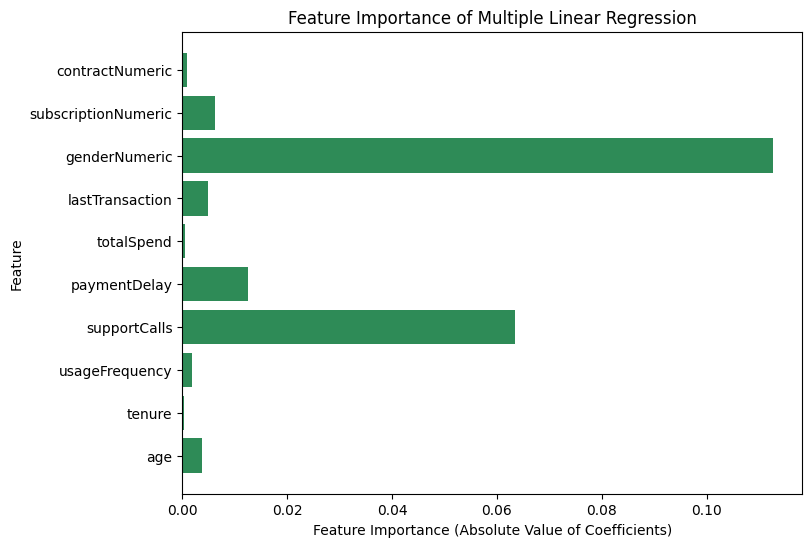

In [46]:
importance = np.abs(reg.params[1:])

plt.figure(figsize = (8, 6))
plt.barh(range(len(importance)), importance, align = 'center', color = 'seagreen')
plt.yticks(np.arange(len(importance)), featureNames)
plt.xlabel("Feature Importance (Absolute Value of Coefficients)")
plt.ylabel("Feature")
plt.title("Feature Importance of Multiple Linear Regression")
plt.show